Loading the dataset: CIFAR-10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


Visualize the data

<Figure size 393.701x393.701 with 0 Axes>

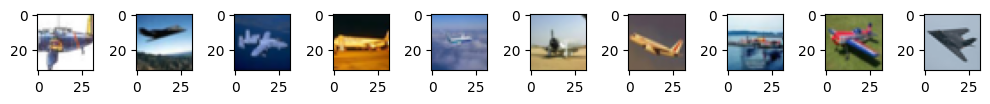

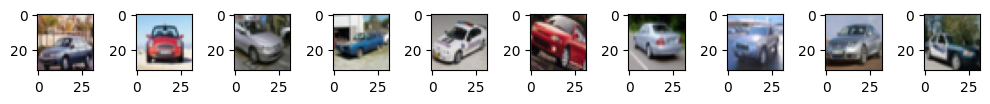

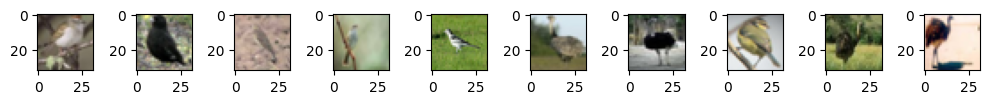

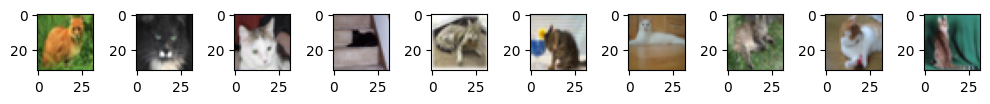

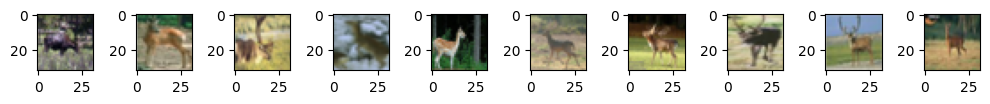

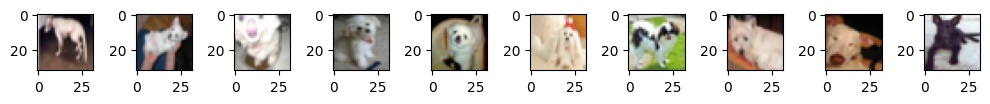

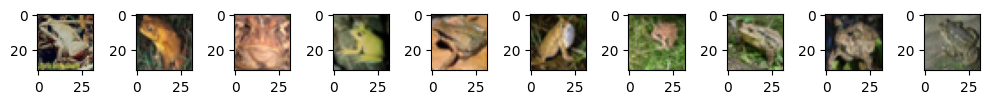

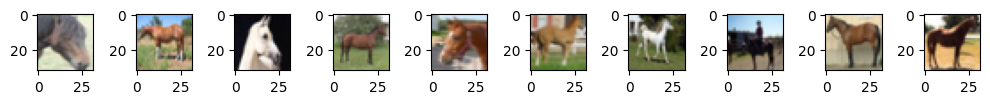

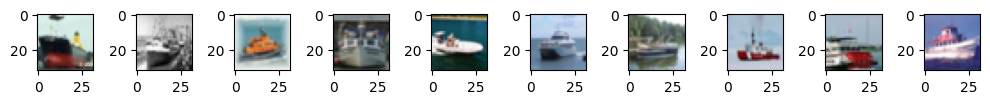

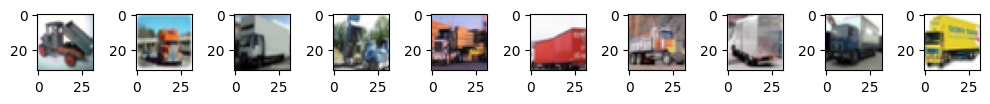

In [3]:

# print(x_train.shape)

num_classes = 10

#add class names

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

fig = plt.figure(figsize=(10*1/2.54, 10*1/2.54))

for idx_class in range(num_classes):

  all_idx = np.where(y_train.flatten() == idx_class)[0]

  # random selection of 10 image of each category
  rand_idx = np.random.choice(all_idx, size=10, replace=False)
  selected = x_train[rand_idx]

  plt.figure(figsize=(10, 10))

  for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(selected[i])
    plt.tight_layout()

  plt.show()

Data normalization

In [4]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


Prepare the labels

In [15]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10, 10)
(10000, 10, 10)


Define the first model

In [69]:
from keras.backend import clear_session
clear_session()

In [70]:
input_shape = (32, 32, 3)

modelRTS01 = Sequential(
    [
        keras.Input(shape=input_shape),


        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D(pool_size=(2,2)),



        layers.Flatten(),

        layers.Dense(256, activation='relu'),

        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ]
)

modelRTS01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,163,978 (4.44 MB)

 Trainable params: 1,163,978 (4.44 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
modelRTS01.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

history = modelRTS01.fit(x_train, y_train, batch_size=128, epochs=50, validation_split=0.2, callbacks=[early_stopping]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3126 - loss: 1.8641 - val_accuracy: 0.5605 - val_loss: 1.2325
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5745 - loss: 1.1940 - val_accuracy: 0.6532 - val_loss: 0.9892
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6666 - loss: 0.9468 - val_accuracy: 0.7000 - val_loss: 0.8568
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7270 - loss: 0.7839 - val_accuracy: 0.7262 - val_loss: 0.7798
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7692 - loss: 0.6682 - val_accuracy: 0.7314 - val_loss: 0.7761
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7974 - loss: 0.5673 - val_accuracy: 0.7385 - val_loss: 0.7595
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8340 - loss: 0.4773 - val_accuracy: 0.7485 - val_loss: 0.7469
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8632 - loss: 0.3868 - val_acc

Test loss: 0.8757977485656738
Test accuracy: 0.7537999749183655
Validation accuracy: 0.8757977485656738
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


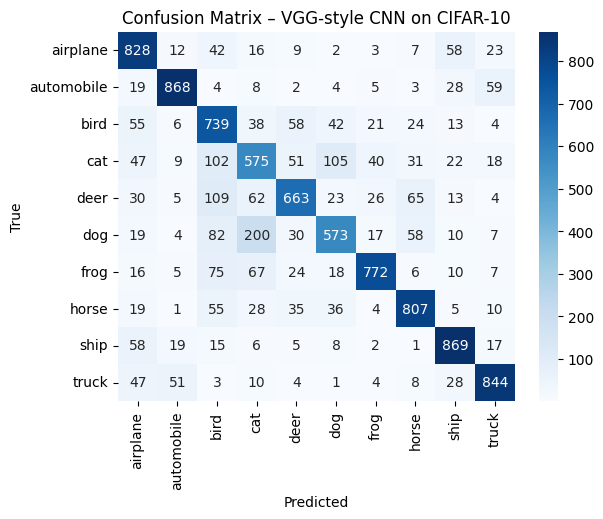

In [72]:
score = modelRTS01.evaluate(x_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Validation accuracy:", score[0])

y_test_pred_prob = modelRTS01.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – VGG-style CNN on CIFAR-10")
plt.show()

In [73]:
print(history.history.keys())
print("Train accuracy:", history.history["accuracy"][-1])
print("Train loss:", history.history["loss"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.8981999754905701
Train loss: 0.2832964360713959
Validation accuracy: 0.7574999928474426
Validation loss: 0.8539395332336426


In [12]:
import os
print("Working directory:", os.getcwd())
print("Files here:", os.listdir())


# Save full model (best default)
modelRTS01.save("cifar10.v1_G1_cnn.keras")


Working directory: /content
Files here: ['.config', 'sample_data']
